In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
print("VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0)

CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Ti
VRAM (GB): 12.878086144


Loading the base model with QLoRA

In [2]:
from unsloth import FastLanguageModel
import torch

max_seq_length =1024  
dtype = None           
load_in_4bit= True  

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name= "unsloth/Qwen2.5-3B-Instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha= 32,
    lora_dropout=0,          # 0 is optimized/faster in Unsloth
    bias= "none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config= None,
)

model.print_trainable_parameters()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.7.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4070 Ti. Num GPUs = 1. Max memory: 11.994 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Unsloth 2026.7.4 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


In [3]:
from datasets import load_dataset

DATA_PATH = r"/home/nmana/json-extractor-sft/data/sft_dataset.jsonl"  

raw_dataset = load_dataset("json", data_files=DATA_PATH, split="train")
print(raw_dataset)
print(raw_dataset[0])

Dataset({
    features: ['messages'],
    num_rows: 1002
})
{'messages': [{'role': 'system', 'content': 'You are a JSON extraction engine. You only output valid JSON. You never include explanations, greetings, disclaimers, markdown formatting, or code. If a requested field is not present in the input, set its value to null. If the user asks for anything other than data extraction, respond with {"error": "unsupported_request", "message": "This model only performs structured data extraction."}'}, {'role': 'user', 'content': "Extract the order ID, customer name, item list, total amount, and tracking number from this order-related text.\n\nI AM SO MAD. I placed order GHI-555-JKL on Tuesday for my wife, Susan Miller. I bought the 'Luxury Spa Gift Set' and the 'Aromatherapy Diffuser'. The total came to $89.99. You sent me tracking number FEDEX-583920485739 but it says it's already delivered and I NEVER GOT IT. This is unacceptable!"}, {'role': 'assistant', 'content': '{"order_id": "GHI-555-J

In [4]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    chat_template="qwen-2.5",  # matches Qwen2.5-Instruct's native template
)

def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [
        tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False)
        for convo in convos
    ]
    return {"text": texts}

dataset = raw_dataset.map(formatting_prompts_func, batched=True)
print(dataset[0]["text"])

<|im_start|>system
You are a JSON extraction engine. You only output valid JSON. You never include explanations, greetings, disclaimers, markdown formatting, or code. If a requested field is not present in the input, set its value to null. If the user asks for anything other than data extraction, respond with {"error": "unsupported_request", "message": "This model only performs structured data extraction."}<|im_end|>
<|im_start|>user
Extract the order ID, customer name, item list, total amount, and tracking number from this order-related text.

I AM SO MAD. I placed order GHI-555-JKL on Tuesday for my wife, Susan Miller. I bought the 'Luxury Spa Gift Set' and the 'Aromatherapy Diffuser'. The total came to $89.99. You sent me tracking number FEDEX-583920485739 but it says it's already delivered and I NEVER GOT IT. This is unacceptable!<|im_end|>
<|im_start|>assistant
{"order_id": "GHI-555-JKL", "customer_name": "Susan Miller", "items": ["Luxury Spa Gift Set", "Aromatherapy Diffuser"], "

Train/Test Split

In [5]:
split_dataset = dataset.train_test_split(test_size=0.05, seed=3407)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]
print("train size:", len(train_dataset), "| eval size:", len(eval_dataset))

train size: 951 | eval size: 51


TRAINING

In [6]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=SFTConfig(
        dataset_text_field="text",
        max_length=1024,
        padding_free=False,        # <-- explicitly disable, avoids the padding_free+no-packing check
        dataset_num_proc=2,
        packing=False,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_steps=10,
        num_train_epochs=3,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=25,
        save_strategy="steps",
        save_steps=50,
        save_total_limit=2,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
        report_to="none",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/951 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/51 [00:00<?, ? examples/s]

In [7]:
from unsloth.chat_templates import train_on_responses_only

trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user\n",
    response_part="<|im_start|>assistant\n",
)

Map:   0%|          | 0/951 [00:00<?, ? examples/s]

Map:   0%|          | 0/51 [00:00<?, ? examples/s]

In [8]:
# Check current VRAM usage before training
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"GPU: {gpu_stats.name}, total memory {gpu_stats.total_memory / 1024**3:.2f} GB")
print(f"Reserved before training: {start_gpu_memory} GB")

GPU: NVIDIA GeForce RTX 4070 Ti, total memory 11.99 GB
Reserved before training: 2.117 GB


In [9]:
import sys
print(sys.executable)

/home/nmana/json-extractor-sft/json_env/bin/python


In [10]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 951 | Num Epochs = 3 | Total steps = 180
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
25,0.177843,0.162919
50,0.005952,0.164859
75,0.002746,0.175826
100,0.003240,0.175053
125,0.001359,0.181798
150,0.000161,0.186470
175,0.001022,0.187856
180,0.000713,0.187309


/home/nmana/json-extractor-sft/json_env/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/nmana/json-extractor-sft/json_env/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/nmana/json-extractor-sft/json_env/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConve

In [11]:
# Post-training memory/time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"Peak reserved memory: {used_memory} GB")
print(f"Training time: {trainer_stats.metrics['train_runtime']:.1f} sec "
      f"({trainer_stats.metrics['train_runtime']/60:.1f} min)")

Peak reserved memory: 4.312 GB
Training time: 354.7 sec (5.9 min)


Visualize the training loss curves

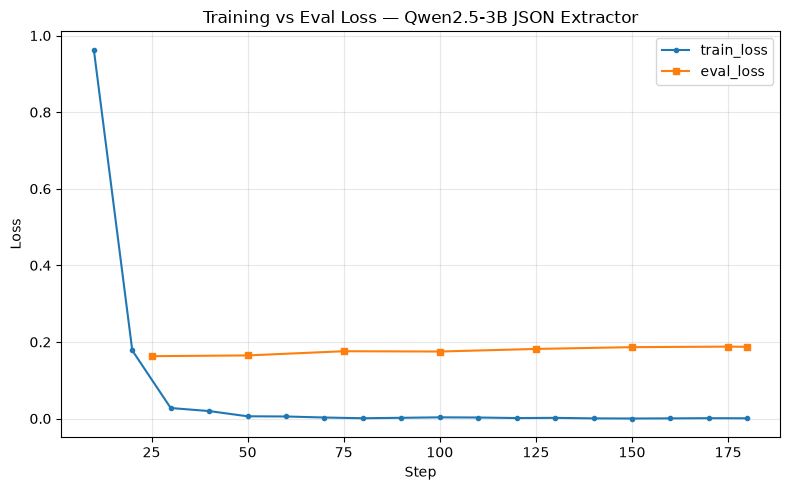

Saved plot to loss_curve.png


In [12]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

for entry in history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label="train_loss", marker="o", markersize=3)
plt.plot(eval_steps, eval_losses, label="eval_loss", marker="s", markersize=4)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Eval Loss — Qwen2.5-3B JSON Extractor")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

print("Saved plot to loss_curve.png")


Test interface

In [ ]:
FastLanguageModel.for_inference(model)  # enables Unsloth's faster inference path

SYSTEM_PROMPT = (
    "You are a JSON extraction engine. You only output valid JSON. "
    "You never include explanations, greetings, disclaimers, markdown formatting, or code. "
    "If a requested field is not present in the input, set its value to null. "
    "If the user asks for anything other than data extraction, respond with "
    '{"error": "unsupported_request", "message": "This model only performs structured data extraction."}'
)

def run_extraction(user_prompt, max_new_tokens=256):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        input_ids=inputs,
        max_new_tokens=max_new_tokens,
        use_cache=True,
        temperature=0.1,  # low temp: we want deterministic, non-creative JSON
        do_sample=False,
    )
    decoded = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
    return decoded

test_prompt = (
    "Extract the order ID, customer name, item list, total amount, and tracking number from this order-related text.\n\n"
    "Order #AX-102-991 placed by Jonathan Reyes for a 'Wireless Mouse'. "
    "Total was $24.50. No tracking number provided yet."
)

print(run_extraction(test_prompt))


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/nmana/json-extractor-sft/json_env/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/nmana/json-extractor-sft/json_env/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning:

{"order_id": "AX-102-991", "customer_name": "Jonathan Reyes", "item_list": ["Wireless Mouse"], "total_amount": 24.50, "tracking_number": null}


In [14]:
print(run_extraction("Can you write me a poem about the ocean instead?"))

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{"error": "unsupported_request", "message": "This model only performs structured data extraction."}


Save the model

In [15]:
model.save_pretrained("qwen2.5-3b-json-extractor-lora")
tokenizer.save_pretrained("qwen2.5-3b-json-extractor-lora")

Unsloth: Restored added_tokens_decoder metadata in qwen2.5-3b-json-extractor-lora/tokenizer_config.json.


('qwen2.5-3b-json-extractor-lora/tokenizer_config.json',
 'qwen2.5-3b-json-extractor-lora/chat_template.jinja',
 'qwen2.5-3b-json-extractor-lora/tokenizer.json')